# Music4All Data Check

This notebook performs a non-destructive health check for the `music4all` dataset symlinked into this repo.

Checks included:
- path/symlink validation
- dataset size and file counts
- extension distribution
- largest files
- data quality signals (empty files, duplicate basenames, long paths)
- random audio file metadata sample

In [1]:
from pathlib import Path
import os

DATA_PATH = Path('./music4all')
print('DATA_PATH:', DATA_PATH.resolve())
print('Exists:', DATA_PATH.exists())
print('Is symlink:', DATA_PATH.is_symlink())
if DATA_PATH.is_symlink():
    try:
        print('Symlink target:', os.readlink(DATA_PATH))
    except OSError as e:
        print('Symlink read error:', e)

DATA_PATH: /Users/itsnotjerryh/Desktop/music4all
Exists: True
Is symlink: True
Symlink target: /Users/itsnotjerryh/Desktop/music4all


In [2]:
from collections import Counter

file_count = 0
dir_count = 0
total_size = 0
ext_counter = Counter()

for root, dirs, files in os.walk(DATA_PATH):
    dir_count += len(dirs)
    for name in files:
        file_count += 1
        p = Path(root) / name
        try:
            sz = p.stat().st_size
            total_size += sz
        except OSError:
            continue
        ext = p.suffix.lower() if p.suffix else '[no_ext]'
        ext_counter[ext] += 1

avg_size = (total_size / file_count) if file_count else 0
print(f'Total files: {file_count:,}')
print(f'Total dirs: {dir_count:,}')
print(f'Total size (GB): {total_size / (1024**3):.2f}')
print(f'Average file size (KB): {avg_size / 1024:.2f}')

print('\nTop 20 extensions:')
for ext, cnt in ext_counter.most_common(20):
    print(f'{ext:12} {cnt:,}')

Total files: 218,546
Total dirs: 2
Total size (GB): 48.85
Average file size (KB): 234.39

Top 20 extensions:
.txt         109,270
.mp3         109,269
.csv         6
[no_ext]     1


In [3]:
largest = []

for root, _, files in os.walk(DATA_PATH):
    for name in files:
        p = Path(root) / name
        try:
            sz = p.stat().st_size
            largest.append((sz, p))
        except OSError:
            continue

largest.sort(reverse=True, key=lambda x: x[0])
print('Top 20 largest files:')
for sz, p in largest[:20]:
    rel = p.relative_to(DATA_PATH)
    print(f'{sz / (1024**2):8.2f} MB  {rel}')

Top 20 largest files:
  233.90 MB  listening_history.csv
   10.13 MB  id_metadata.csv
    6.68 MB  id_information.csv
    6.19 MB  id_tags.csv
    4.02 MB  id_genres.csv
    2.16 MB  id_lang.csv
    0.46 MB  audios/fXO7aH7NFHfPHUgo.mp3
    0.46 MB  audios/UV96BARf3ciHwFi6.mp3
    0.46 MB  audios/EltvFIDOgIJJPsRi.mp3
    0.46 MB  audios/pRAt7KPOlZHhsI7g.mp3
    0.46 MB  audios/H76ZgXV3ezbegV6Q.mp3
    0.46 MB  audios/q97aAGICNlTDEw0y.mp3
    0.46 MB  audios/ifZzE5d3PR3NWps8.mp3
    0.46 MB  audios/LcoVEb8KiamNvB79.mp3
    0.46 MB  audios/mg64kvNkthr7LzrB.mp3
    0.46 MB  audios/UTot28p6C4VULfhX.mp3
    0.46 MB  audios/O99YmvJi1ifuJIjp.mp3
    0.46 MB  audios/Ln6zoT1SC8WzjeXK.mp3
    0.46 MB  audios/Fz7DkWlg01BwI2SX.mp3
    0.46 MB  audios/LrAwRs5CUUTV0tx5.mp3


In [4]:
from collections import defaultdict

zero_byte = 0
dup_basename = defaultdict(int)
long_paths = 0

for root, _, files in os.walk(DATA_PATH):
    for name in files:
        p = Path(root) / name
        dup_basename[name] += 1
        if len(str(p)) > 240:
            long_paths += 1
        try:
            if p.stat().st_size == 0:
                zero_byte += 1
        except OSError:
            pass

duplicates = sorted(((k, v) for k, v in dup_basename.items() if v > 1), key=lambda x: x[1], reverse=True)

print('Data quality signals:')
print(f'Zero-byte files: {zero_byte:,}')
print(f'Paths >240 chars: {long_paths:,}')
print(f'Duplicate basenames: {len(duplicates):,}')
print('\nTop 20 repeated basenames:')
for name, cnt in duplicates[:20]:
    print(f'{cnt:6}  {name.encode("utf-8", errors="replace").decode("utf-8")}')

Data quality signals:
Zero-byte files: 0
Paths >240 chars: 0
Duplicate basenames: 0

Top 20 repeated basenames:


In [5]:
import random
from datetime import datetime

audio_exts = {'.mp3', '.wav', '.flac', '.m4a', '.aac', '.ogg'}
audio_files = []

for root, _, files in os.walk(DATA_PATH):
    for name in files:
        p = Path(root) / name
        if p.suffix.lower() in audio_exts:
            audio_files.append(p)

print(f'Found audio files: {len(audio_files):,}')
sample_n = min(5, len(audio_files))
print(f'Random sample size: {sample_n}')

for p in random.sample(audio_files, sample_n) if sample_n else []:
    st = p.stat()
    print('-' * 80)
    print('file:', p.relative_to(DATA_PATH))
    print('size_mb:', round(st.st_size / (1024**2), 3))
    print('modified:', datetime.fromtimestamp(st.st_mtime).isoformat(timespec='seconds'))

Found audio files: 109,269
Random sample size: 5
--------------------------------------------------------------------------------
file: audios/yfQqp4q6Q1s1cv0q.mp3
size_mb: 0.458
modified: 2019-12-04T19:29:34
--------------------------------------------------------------------------------
file: audios/MALWpcdq0bntyUiI.mp3
size_mb: 0.458
modified: 2019-12-04T19:26:58
--------------------------------------------------------------------------------
file: audios/LKcNRg4vRYh1L0nE.mp3
size_mb: 0.229
modified: 2019-12-04T19:48:43
--------------------------------------------------------------------------------
file: audios/c53bh7Hkdmkuniet.mp3
size_mb: 0.458
modified: 2019-12-04T19:22:23
--------------------------------------------------------------------------------
file: audios/L5bQ37pq3PcoVtDn.mp3
size_mb: 0.458
modified: 2019-12-04T19:37:11


## 4. Dataset Description and Suitability

### Dataset overview
This project uses the **Music4All** dataset (mounted via symlink at `./music4all`). Based on the dataset scan:
- Total size is approximately **48.85 GB**.
- It contains **109,269 audio clips** (`.mp3`) and paired text/metadata resources.
- Key tabular files include `listening_history.csv`, `id_metadata.csv`, `id_information.csv`, `id_tags.csv`, `id_genres.csv`, and `id_lang.csv`.

### Why this dataset is suitable
This dataset is suitable for a recommender-system workflow because it combines:
1. **User–item interaction signal** (from listening history),
2. **Item content signal** (audio files), and
3. **Item metadata signal** (language, tags, genre, information tables).

This supports multiple recommendation paradigms in one benchmark:
- collaborative filtering,
- content-based recommendation,
- and hybrid approaches.

### EDA goals
In the next cells, we perform EDA to:
- inspect major CSV tables,
- profile schema and missingness,
- and visualize key distributions useful for modeling decisions.

In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path('./music4all')

key_csvs = [
    'listening_history.csv',
    'id_metadata.csv',
    'id_information.csv',
    'id_tags.csv',
    'id_genres.csv',
    'id_lang.csv',
]

rows = []
for name in key_csvs:
    p = DATA_PATH / name
    exists = p.exists()
    size_mb = p.stat().st_size / (1024**2) if exists else None
    rows.append({'file': name, 'exists': exists, 'size_mb': round(size_mb, 2) if size_mb is not None else None})

pd.DataFrame(rows)

,file,exists,size_mb
0,listening_history.csv,True,233.90
1,id_metadata.csv,True,10.13
2,id_information.csv,True,6.68
3,id_tags.csv,True,6.19
4,id_genres.csv,True,4.02
5,id_lang.csv,True,2.16


In [7]:
def load_tsv_like(csv_path, sample_rows=50000):
    with open(csv_path, 'r', encoding='utf-8', errors='replace') as f:
        header = f.readline().rstrip('\n\r')

        # Detect whether separator is real tab or literal "\\t"
        if '\t' in header:
            sep = '\t'
            sep_name = 'tab'
        elif '\\t' in header:
            sep = '\\t'
            sep_name = 'literal_\\t'
        else:
            sep = ','
            sep_name = 'comma'

        cols = header.split(sep)

        records = []
        for i, line in enumerate(f):
            if i >= sample_rows:
                break
            parts = line.rstrip('\n\r').split(sep)
            if len(parts) < len(cols):
                parts += [None] * (len(cols) - len(parts))
            elif len(parts) > len(cols):
                parts = parts[:len(cols)-1] + [sep.join(parts[len(cols)-1:])]
            records.append(parts)

    df = pd.DataFrame(records, columns=cols)
    return df, sep_name


def quick_profile(csv_path, sample_rows=50000):
    df, sep_used = load_tsv_like(csv_path, sample_rows=sample_rows)
    info = {
        'file': csv_path.name,
        'sep_used': sep_used,
        'sample_rows_loaded': len(df),
        'num_columns': df.shape[1],
        'columns': list(df.columns)
    }
    missing = (df.isna().mean() * 100).sort_values(ascending=False)
    return df, info, missing

profiles = {}
for name in ['id_metadata.csv', 'id_information.csv', 'id_tags.csv', 'id_genres.csv', 'id_lang.csv']:
    p = DATA_PATH / name
    if p.exists():
        try:
            df, info, missing = quick_profile(p)
            profiles[name] = {'df': df, 'info': info, 'missing': missing}
            print(f"\n{name}")
            print(f"sep_used={info['sep_used']}, sample_rows_loaded={info['sample_rows_loaded']}, num_columns={info['num_columns']}")
            print('columns:', info['columns'][:12], '...' if len(info['columns']) > 12 else '')
            print('top missing (%):')
            print(missing.head(10).round(2))
        except Exception as e:
            print(f"\n{name} -> failed to load: {e}")


id_metadata.csv
sep_used=tab, sample_rows_loaded=50000, num_columns=11
columns: ['id', 'spotify_id', 'popularity', 'release', 'danceability', 'energy', 'key', 'mode', 'valence', 'tempo', 'duration_ms'] 
top missing (%):
id              0.0
spotify_id      0.0
popularity      0.0
release         0.0
danceability    0.0
energy          0.0
key             0.0
mode            0.0
valence         0.0
tempo           0.0
dtype: float64

id_information.csv
sep_used=tab, sample_rows_loaded=50000, num_columns=4
columns: ['id', 'artist', 'song', 'album_name'] 
top missing (%):
id            0.0
artist        0.0
song          0.0
album_name    0.0
dtype: float64

id_tags.csv
sep_used=tab, sample_rows_loaded=50000, num_columns=2
columns: ['id', 'tags'] 
top missing (%):
id      0.0
tags    0.0
dtype: float64

id_genres.csv
sep_used=tab, sample_rows_loaded=50000, num_columns=2
columns: ['id', 'genres'] 
top missing (%):
id        0.0
genres    0.0
dtype: float64

id_lang.csv
sep_used=tab, sample

listening_history sample shape: (300000, 3)
columns: ['user', 'song', 'timestamp']

Users in sample: 840
Avg interactions/user: 357.14
Median interactions/user: 374


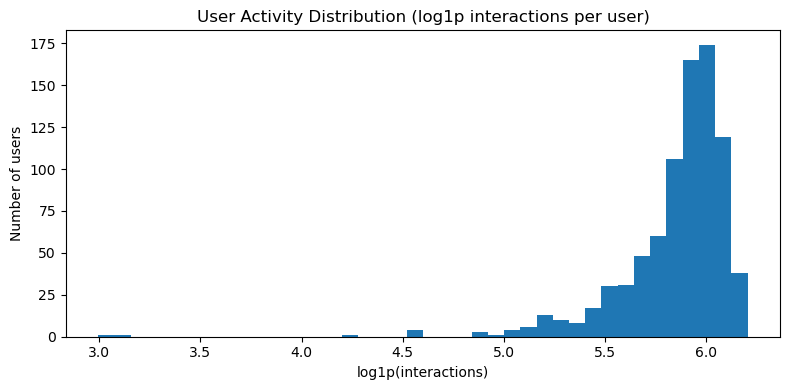

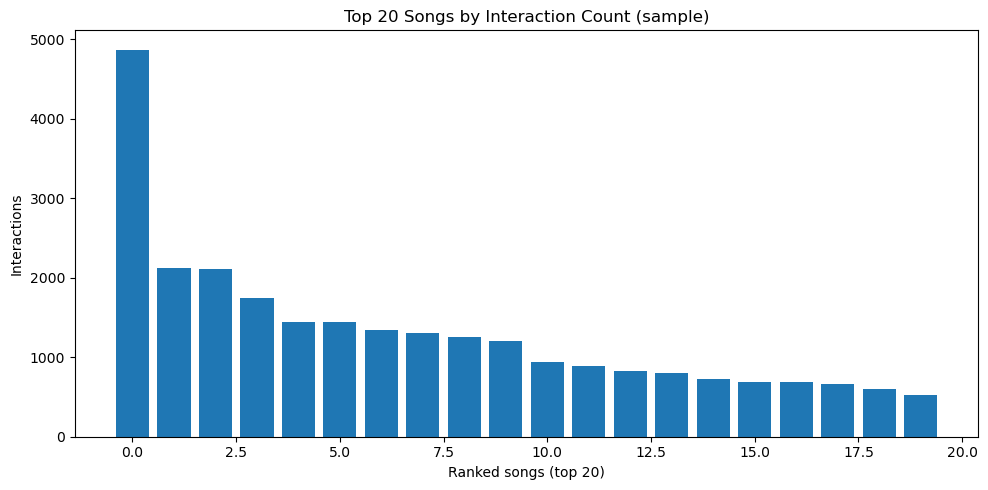

,count
song,
32m5suoC94ytD8Ed,4871
vkOg9ZAiUgUT87k6,2124
YwURIu6eZDCJyuEf,2106
7Gsb7yKtAJNCvWez,1749
KKmk2QJLVj2Aqsjg,1445
8LgQbYbM6Vz2my0y,1443
Pf7CTDMAqnLhbcY2,1349
xMkeAOwn6AzEeYGh,1301
yruqkezbERogpi3F,1250


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# In-depth analysis on listening_history.csv
lh_path = DATA_PATH / 'listening_history.csv'
lh = pd.read_csv(lh_path, nrows=300000, sep='\t', engine='python', on_bad_lines='skip')

# Basic sanity
print('listening_history sample shape:', lh.shape)
print('columns:', list(lh.columns))

# 1) Interactions per user (activity distribution)
user_activity = lh.groupby('user').size().sort_values(ascending=False)
print('\nUsers in sample:', user_activity.shape[0])
print('Avg interactions/user:', round(user_activity.mean(), 2))
print('Median interactions/user:', int(user_activity.median()))

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(user_activity.values), bins=40)
plt.title('User Activity Distribution (log1p interactions per user)')
plt.xlabel('log1p(interactions)')
plt.ylabel('Number of users')
plt.tight_layout()
plt.show()

# 2) Top songs by interaction count (long-tail glimpse)
top_songs = lh.groupby('song').size().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 5))
plt.bar(range(len(top_songs)), top_songs.values)
plt.title('Top 20 Songs by Interaction Count (sample)')
plt.xlabel('Ranked songs (top 20)')
plt.ylabel('Interactions')
plt.tight_layout()
plt.show()

display(top_songs.head(10).rename('count').to_frame())

/var/folders/28/1r050w4j7j5c4jn87rdsh2hw0000gn/T/ipykernel_48930/2661871111.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = parsed.dt.to_period('M').value_counts().sort_index()


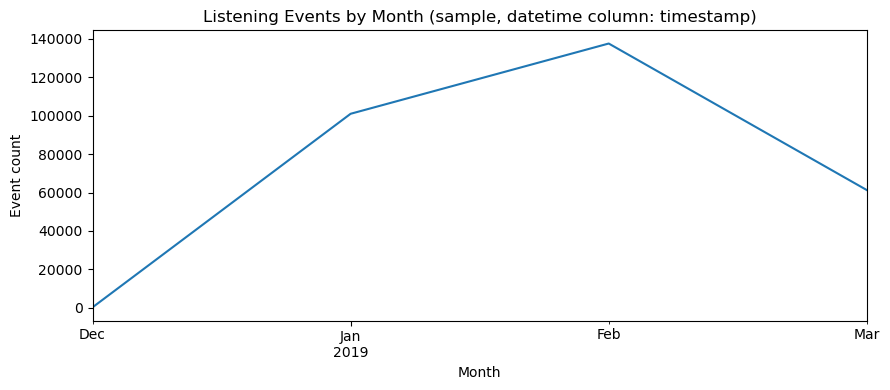

timestamp
2018-12       264
2019-01    100959
2019-02    137507
2019-03     61270
Freq: M, Name: count, dtype: int64

In [13]:
# Listening history trend (tab-separated)
lh_path = DATA_PATH / 'listening_history.csv'

if lh_path.exists():
    lh = pd.read_csv(lh_path, nrows=300000, sep='\t', engine='python', on_bad_lines='skip')

    dt_candidates = [c for c in lh.columns if any(k in c.lower() for k in ['time', 'date', 'timestamp'])]

    parsed = None
    used_col = None
    for c in dt_candidates:
        s = pd.to_datetime(lh[c], errors='coerce', utc=True)
        valid_ratio = s.notna().mean()
        if valid_ratio > 0.6:
            parsed = s
            used_col = c
            break

    if parsed is not None:
        monthly = parsed.dt.to_period('M').value_counts().sort_index()
        plt.figure(figsize=(9, 4))
        monthly.plot(kind='line')
        plt.title(f'Listening Events by Month (sample, datetime column: {used_col})')
        plt.xlabel('Month')
        plt.ylabel('Event count')
        plt.tight_layout()
        plt.show()
        display(monthly.tail(12))
    else:
        print('No reliable datetime column detected in listening_history.csv sample.')
        print('Columns found:', list(lh.columns))
else:
    print('listening_history.csv not found.')

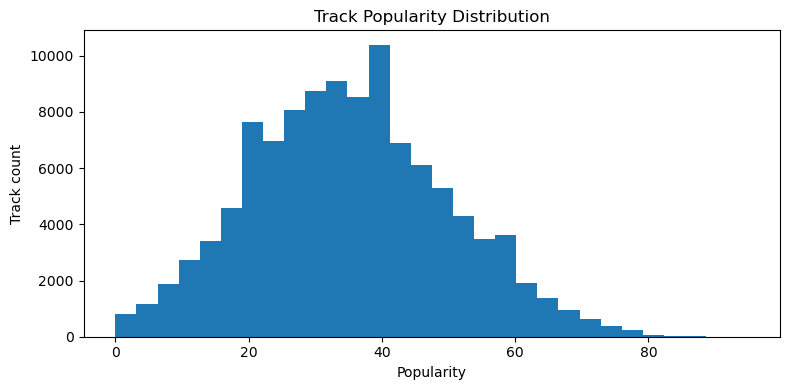

Popularity mean: 35.08 | median: 34.0


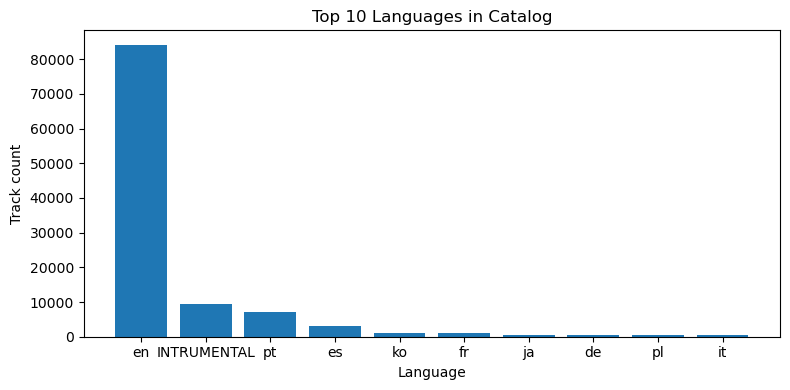

,count
lang,
en,84103
INTRUMENTAL,9417
pt,7020
es,3225
ko,1145
fr,994
ja,615
de,577
pl,446


In [14]:
# Metadata-focused analysis: language distribution + popularity distribution
meta_path = DATA_PATH / 'id_metadata.csv'
lang_path = DATA_PATH / 'id_lang.csv'

meta = pd.read_csv(meta_path, sep='\t', engine='python', on_bad_lines='skip')
lang = pd.read_csv(lang_path, sep='\t', engine='python', on_bad_lines='skip')

# Popularity distribution
if 'popularity' in meta.columns:
    pop = pd.to_numeric(meta['popularity'], errors='coerce').dropna()
    plt.figure(figsize=(8, 4))
    plt.hist(pop, bins=30)
    plt.title('Track Popularity Distribution')
    plt.xlabel('Popularity')
    plt.ylabel('Track count')
    plt.tight_layout()
    plt.show()
    print('Popularity mean:', round(pop.mean(), 2), '| median:', round(pop.median(), 2))

# Top languages
if 'lang' in lang.columns:
    top_lang = lang['lang'].astype(str).value_counts().head(10)
    plt.figure(figsize=(8, 4))
    plt.bar(top_lang.index, top_lang.values)
    plt.title('Top 10 Languages in Catalog')
    plt.xlabel('Language')
    plt.ylabel('Track count')
    plt.tight_layout()
    plt.show()
    display(top_lang.rename('count').to_frame())

### Report-ready takeaway

This EDA confirms that Music4All provides a strong basis for recommendation modeling:
- large item catalog with paired audio and metadata,
- availability of interaction logs for implicit feedback modeling,
- manageable data quality (no zero-byte files in the scanned corpus).

These properties justify using this dataset for collaborative, content-based, and hybrid recommendation experiments.